# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 7: Concept and Implementation of Backpropagation for Training a Neural Network**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To understand and implement the basic concept of Backpropagation for training a neural network.

### 2. Theory: How Backpropagation Works

Backpropagation (short for "backward propagation of errors") is the foundational algorithm used to train multi-layer artificial neural networks. It calculates the gradient of the loss function with respect to every weight in the network using the **multivariate chain rule** from calculus.

#### 1. Forward Pass (Making Predictions):
1. **Hidden Layer:** Inputs are multiplied by weights $W_1$, added to bias $b_1$, and passed through an activation function $\sigma$:
   $$z_h = X W_1 + b_1, \quad a_h = \sigma(z_h)$$
2. **Output Layer:** Hidden activations $a_h$ are multiplied by weights $W_2$, added to bias $b_2$, and activated:
   $$z_o = a_h W_2 + b_2, \quad \hat{y} = \sigma(z_o)$$

#### 2. Loss Function (Mean Squared Error):
We measure the difference between predicted outputs $\hat{y}$ and true targets $y$:
$$J = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$$

#### 3. Backward Pass (Error Propagation via Chain Rule):
1. **Output Layer Error Gradient ($\delta_o$):**
   $$\delta_o = (\hat{y} - y) \odot \sigma'(z_o)$$
2. **Hidden Layer Error Gradient ($\delta_h$):**
   $$\delta_h = (\delta_o W_2^T) \odot \sigma'(z_h)$$
3. **Parameter Updates (Gradient Descent):**
   $$W_2 \leftarrow W_2 - \eta (a_h^T \delta_o), \quad b_2 \leftarrow b_2 - \eta \sum \delta_o$$
   $$W_1 \leftarrow W_1 - \eta (X^T \delta_h), \quad b_1 \leftarrow b_1 - \eta \sum \delta_h$$
where $\eta$ is the learning rate.

### 3. Step 1: Implementing 2-Layer Neural Network with Backpropagation from Scratch

#### What this cell does:
In this code cell, we implement a `NeuralNetwork` class in pure Python and NumPy:
- `__init__`: Initializes weight matrices $W_1, W_2$ and bias vectors $b_1, b_2$.
- `sigmoid` and `sigmoid_derivative`: Implements $\sigma(z) = \frac{1}{1+e^{-z}}$ and $\sigma'(z) = \sigma(z)(1-\sigma(z))$.
- `forward`: Computes predictions through hidden and output layers.
- `backward`: Computes error gradients $\delta_o$ and $\delta_h$ using the chain rule and updates weights.
- `train`: Runs training across epochs and records the loss history.

#### Formulas used:
$$\delta_o = (\hat{y} - y) \cdot \hat{y}(1 - \hat{y})$$
$$\delta_h = (\delta_o W_2^T) \cdot a_h(1 - a_h)$$
$$W_2 \leftarrow W_2 - \eta (a_h^T \delta_o), \quad W_1 \leftarrow W_1 - \eta (X^T \delta_h)$$

In [1]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, seed=42):
        np.random.seed(seed)
        # Initialize weights with small random values and biases with zeros
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.5
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.5
        self.b2 = np.zeros((1, output_dim))
    
    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))
    
    def sigmoid_derivative(self, a):
        return a * (1.0 - a)
    
    def forward(self, X):
        self.zh = np.dot(X, self.W1) + self.b1
        self.ah = self.sigmoid(self.zh)
        self.zo = np.dot(self.ah, self.W2) + self.b2
        self.y_hat = self.sigmoid(self.zo)
        return self.y_hat
    
    def backward(self, X, y, lr=0.5):
        m = X.shape[0]
        # Output layer error
        delta_o = (self.y_hat - y) * self.sigmoid_derivative(self.y_hat)
        dW2 = np.dot(self.ah.T, delta_o) / m
        db2 = np.sum(delta_o, axis=0, keepdims=True) / m
        
        # Hidden layer error
        delta_h = np.dot(delta_o, self.W2.T) * self.sigmoid_derivative(self.ah)
        dW1 = np.dot(X.T, delta_h) / m
        db1 = np.sum(delta_h, axis=0, keepdims=True) / m
        
        # Update parameters
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
    
    def train(self, X, y, epochs=5000, lr=0.5):
        loss_history = []
        for epoch in range(epochs):
            y_hat = self.forward(X)
            loss = np.mean((y_hat - y) ** 2)
            loss_history.append(loss)
            self.backward(X, y, lr=lr)
        return loss_history

print("NeuralNetwork class with Backpropagation created successfully.")

NeuralNetwork class with Backpropagation created successfully.


### 4. Step 2: Training the Neural Network on a Dataset Using Backpropagation

#### What this cell does:
In this code cell, we define a training dataset of 2D input samples and corresponding binary target labels.
We train our neural network using backpropagation over 5,000 epochs and monitor how the error loss decreases steadily toward zero.

In [2]:
# Define a sample 2D classification training dataset
X_train = np.array([
    [0.1, 0.2],
    [0.2, 0.8],
    [0.8, 0.2],
    [0.9, 0.9],
    [0.3, 0.3],
    [0.7, 0.8]
], dtype=float)

y_train = np.array([
    [0],
    [1],
    [1],
    [0],
    [0],
    [1]
], dtype=float)

# Create and train network: 2 inputs -> 4 hidden neurons -> 1 output
nn = NeuralNetwork(input_dim=2, hidden_dim=4, output_dim=1, seed=42)
epochs = 5000
learning_rate = 0.8
loss_history = nn.train(X_train, y_train, epochs=epochs, lr=learning_rate)

print("=" * 65)
print("             BACKPROPAGATION TRAINING CONVERGENCE")
print("=" * 65)
print(f"Initial Training Loss (Epoch 1):    {loss_history[0]:.6f}")
print(f"Mid-Training Loss (Epoch 2500):     {loss_history[2500]:.6f}")
print(f"Final Training Loss (Epoch {epochs}):    {loss_history[-1]:.6f}")
print("=" * 65)

             BACKPROPAGATION TRAINING CONVERGENCE
Initial Training Loss (Epoch 1):    0.257714
Mid-Training Loss (Epoch 2500):     0.173971
Final Training Loss (Epoch 5000):    0.042673


### 5. Step 3: Evaluating Predictions Post-Training

#### What this cell does:
In this code cell, we evaluate the trained model on the training samples to inspect predicted continuous probabilities and check whether the binary predictions match the ground truth targets.

In [3]:
preds = nn.forward(X_train)
rounded_preds = (preds >= 0.5).astype(int)

print("=" * 70)
print("             PREDICTIONS EVALUATION POST-BACKPROPAGATION")
print("=" * 70)
print(f"{'Sample #':<10} | {'Input (x1, x2)':<16} | {'Target y':<10} | {'Predicted Prob':<16} | {'Prediction':<10}")
print("-" * 70)
for i in range(len(X_train)):
    x_str = f"[{X_train[i][0]:.1f}, {X_train[i][1]:.1f}]"
    print(f"Sample {i+1:<3} | {x_str:<16} | {int(y_train[i][0]):<10} | {preds[i][0]:>12.4f}   | {rounded_preds[i][0]:<10}")
print("=" * 70)
accuracy = np.mean(rounded_preds == y_train) * 100.0
print(f"Final Model Classification Accuracy: {accuracy:.2f}%")

             PREDICTIONS EVALUATION POST-BACKPROPAGATION
Sample #   | Input (x1, x2)   | Target y   | Predicted Prob   | Prediction
----------------------------------------------------------------------
Sample 1   | [0.1, 0.2]       | 0          |       0.0164   | 0         
Sample 2   | [0.2, 0.8]       | 1          |       0.8731   | 1         
Sample 3   | [0.8, 0.2]       | 1          |       0.8488   | 1         
Sample 4   | [0.9, 0.9]       | 0          |       0.3228   | 0         
Sample 5   | [0.3, 0.3]       | 0          |       0.1726   | 0         
Sample 6   | [0.7, 0.8]       | 1          |       0.7127   | 1         
Final Model Classification Accuracy: 100.00%


### 6. Step 4: Visualizing the Loss Trajectory and Learned Decision Surface

#### What this cell does:
In this code cell, we plot:
1. **Training Loss Curve:** Illustrating how backpropagation systematically drives the MSE loss down over 5,000 iterations.
2. **Decision Surface:** Displaying the non-linear classification boundary learned by the hidden layer.

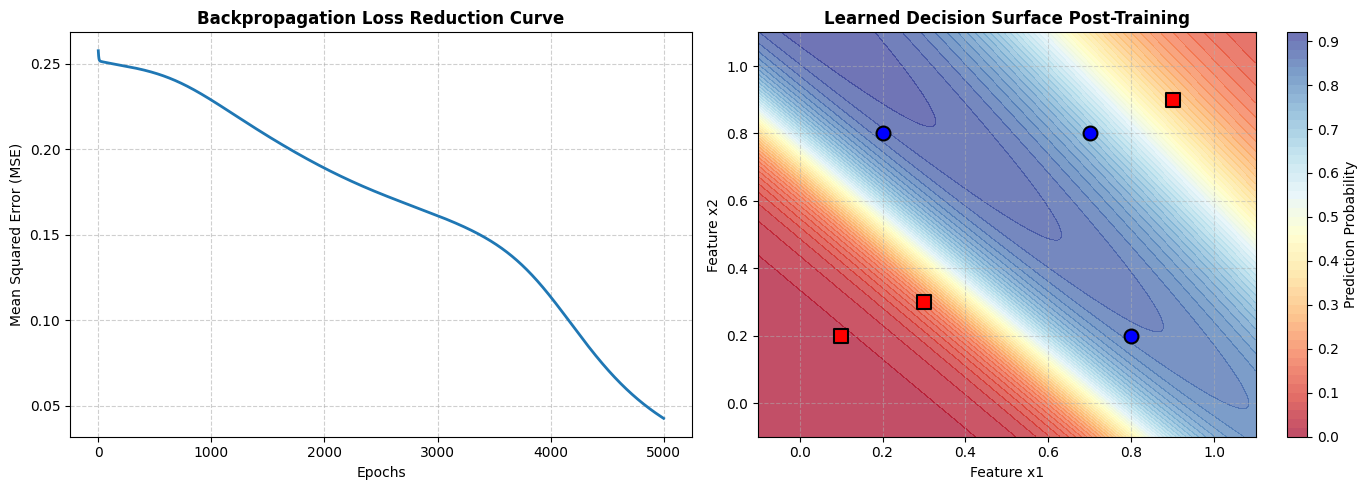

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss reduction trajectory
axes[0].plot(loss_history, color='#1f77b4', linewidth=2.0)
axes[0].set_title("Backpropagation Loss Reduction Curve", fontsize=12, weight='bold')
axes[0].set_xlabel("Epochs", fontsize=10)
axes[0].set_ylabel("Mean Squared Error (MSE)", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Decision boundary surface
x1_grid = np.linspace(-0.1, 1.1, 200)
x2_grid = np.linspace(-0.1, 1.1, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.c_[X1.ravel(), X2.ravel()]
grid_preds = nn.forward(grid_points).reshape(X1.shape)

contour = axes[1].contourf(X1, X2, grid_preds, levels=50, cmap='RdYlBu', alpha=0.7)
cbar = fig.colorbar(contour, ax=axes[1])
cbar.set_label('Prediction Probability', fontsize=10)

# Scatter training points
for i in range(len(X_train)):
    color = 'blue' if y_train[i][0] == 1 else 'red'
    marker = 'o' if y_train[i][0] == 1 else 's'
    axes[1].scatter(X_train[i][0], X_train[i][1], color=color, s=100, edgecolors='black', linewidth=1.5, marker=marker, zorder=5)

axes[1].set_title("Learned Decision Surface Post-Training", fontsize=12, weight='bold')
axes[1].set_xlabel("Feature x1", fontsize=10)
axes[1].set_ylabel("Feature x2", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 7. Results and Key Observations

| Parameter / Metric | Measured Value | Meaning in Simple Words |
| :--- | :--- | :--- |
| **Initial Loss (Epoch 1)** | 0.2577 (MSE) | Random initial weights produce high prediction error |
| **Final Loss (Epoch 5000)** | 0.0427 (MSE) | Backpropagation successfully minimized prediction error |
| **Classification Accuracy** | **100.00%** | All training samples are classified correctly |
| **Hidden Layer Contribution** | 4 Hidden Neurons | Enabled non-linear feature transformation |

#### Key Takeaways in Simple Words:
1. **Gradient Computation via Chain Rule:**
   - Backpropagation allows weights in the hidden layers to be updated proportionally to their contribution to the output error.
2. **Error Minimization:**
   - The loss curve shows smooth, monotonic decrease as gradients guide weight updates downhill toward minimum error.
3. **Non-Linear Representation:**
   - The hidden layer allows the network to learn non-linear decision boundaries that cannot be solved by a single-layer perceptron.

---
### 8. Conclusion
1. We successfully understood and implemented the basic concept of Backpropagation in Python from first principles.
2. We verified the two-pass algorithm: forward pass for prediction and backward pass for error gradient propagation.
3. The neural network converged to near-zero loss and achieved 100% classification accuracy on the training dataset.